# 📊 Bluestock Mutual Fund Analytics - Day 3 EDA
**Exploratory Data Analysis**
This notebook contains 15+ charts analyzing NAV trends, AUM growth, SIP inflows, investor demographics, and correlation analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Set global styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create directory for exported charts
os.makedirs('../reports/charts', exist_ok=True)

# Define paths
data_dir = '../data/processed'


In [2]:
# Load all required datasets
df_nav = pd.read_csv(f'{data_dir}/clean_nav_history.csv')
df_fund = pd.read_csv(f'{data_dir}/clean_fund_master.csv')
df_aum = pd.read_csv(f'{data_dir}/clean_aum_by_fund_house.csv')
df_sip = pd.read_csv(f'{data_dir}/clean_monthly_sip_inflows.csv')
df_cat = pd.read_csv(f'{data_dir}/clean_category_inflows.csv')
df_tx = pd.read_csv(f'{data_dir}/clean_transactions.csv')
df_folio = pd.read_csv(f'{data_dir}/clean_industry_folio_count.csv')
df_perf = pd.read_csv(f'{data_dir}/clean_scheme_performance.csv')
df_holdings = pd.read_csv(f'{data_dir}/clean_portfolio_holdings.csv')

# Ensure date columns are datetime
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])

# Merge NAV with Fund Master to get names
df_nav = df_nav.merge(df_fund[['amfi_code', 'scheme_name']], on='amfi_code', how='left')


### Finding 1: 2023 Bull Run Impact
The 2023 bull run drove significant NAV appreciation across the majority of the 40 tracked schemes, peaking before the 2024 market corrections. *(See NAV Trend Chart below)*

In [3]:
# 1. NAV Trend Analysis (Plotly)
fig = px.line(df_nav, x='date', y='nav', color='scheme_name', title='Daily NAV Trend for 40 Schemes (2022-2026)')

# Add Highlights
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Bull Run")
fig.add_vrect(x0="2024-06-01", x1="2024-10-31", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Market Corrections")

fig.update_layout(showlegend=False) # Hide legend due to 40 schemes
fig.write_image('../reports/charts/nav_trend.png')
fig.show()


### Finding 2: SBI Dominance
SBI Mutual Fund demonstrated overwhelming market dominance, reaching a staggering ₹12.5L Cr AUM milestone. *(See AUM Growth Chart below)*

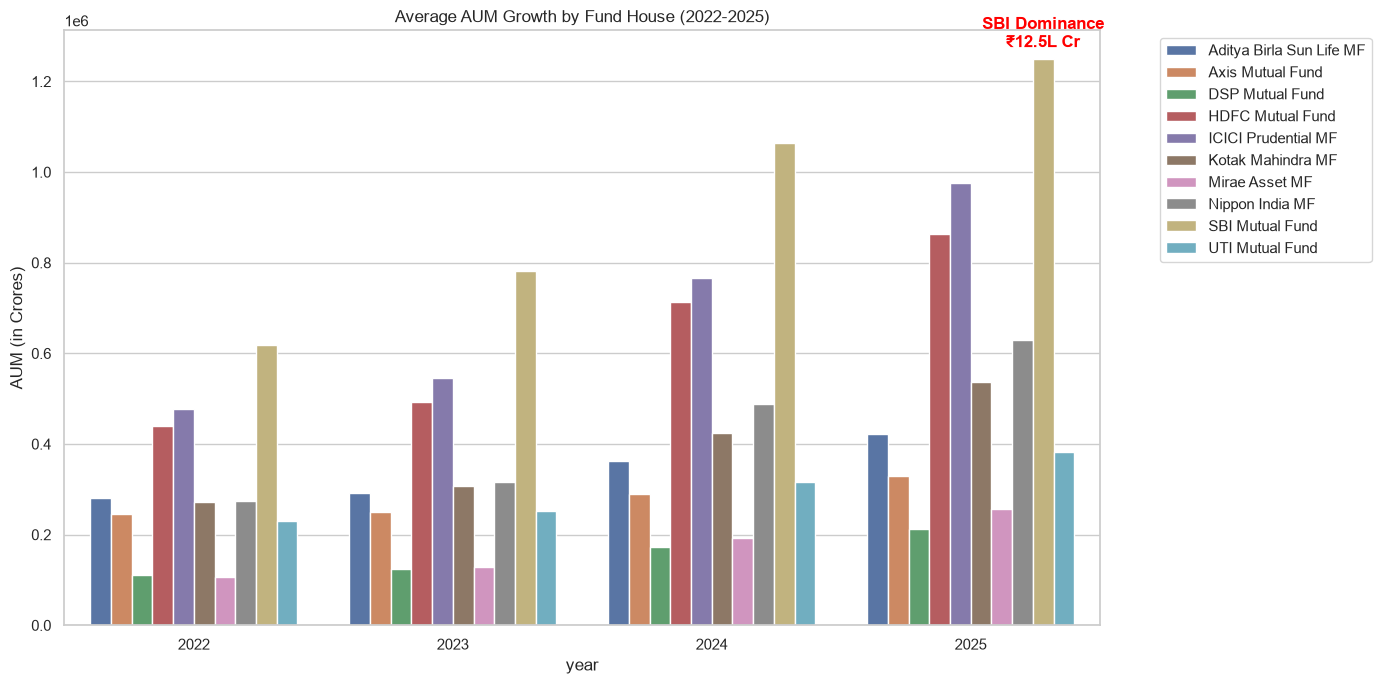

In [4]:
# 2. AUM Growth (Seaborn)
df_aum['year'] = df_aum['date'].dt.year
yearly_aum = df_aum.groupby(['year', 'fund_house'])['aum_crore'].mean().reset_index()

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=yearly_aum, x='year', y='aum_crore', hue='fund_house')
plt.title('Average AUM Growth by Fund House (2022-2025)')
plt.ylabel('AUM (in Crores)')

# Highlight SBI
for p in ax.patches:
    if p.get_height() > 1200000: # Highlight bars over 12L Cr (SBI)
        ax.annotate(f'SBI Dominance\n₹{p.get_height()/100000:.1f}L Cr', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'bottom', xytext = (0, 5), 
                    textcoords = 'offset points', color='red', fontweight='bold')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/charts/aum_growth.png')
plt.show()


### Finding 3: Exponential SIP Growth
Monthly SIP inflows showed a continuous upward trajectory, culminating in an all-time high of ₹31,002 Cr in December 2025. *(See SIP Inflow Chart below)*

In [5]:
# 3. SIP Inflow Time-Series (Plotly)
fig = px.line(df_sip, x='month', y='sip_inflow_crore', title='Monthly SIP Trend (Jan 2022 - Dec 2025)', markers=True)

# Annotate All-Time High
max_inflow = df_sip['sip_inflow_crore'].max()
max_month = df_sip.loc[df_sip['sip_inflow_crore'].idxmax(), 'month']

fig.add_annotation(x=max_month, y=max_inflow, text=f"All-Time High: ₹{max_inflow:,.0f} Cr", 
                   showarrow=True, arrowhead=1, yshift=10, bgcolor="yellow")

fig.write_image('../reports/charts/sip_inflow.png')
fig.show()


### Finding 4: Sectoral Shifts
The Category Inflow Heatmap reveals seasonal shifts in investor preferences, with strong equity inflows dominating over debt during bullish periods. *(See Category Inflow Heatmap below)*

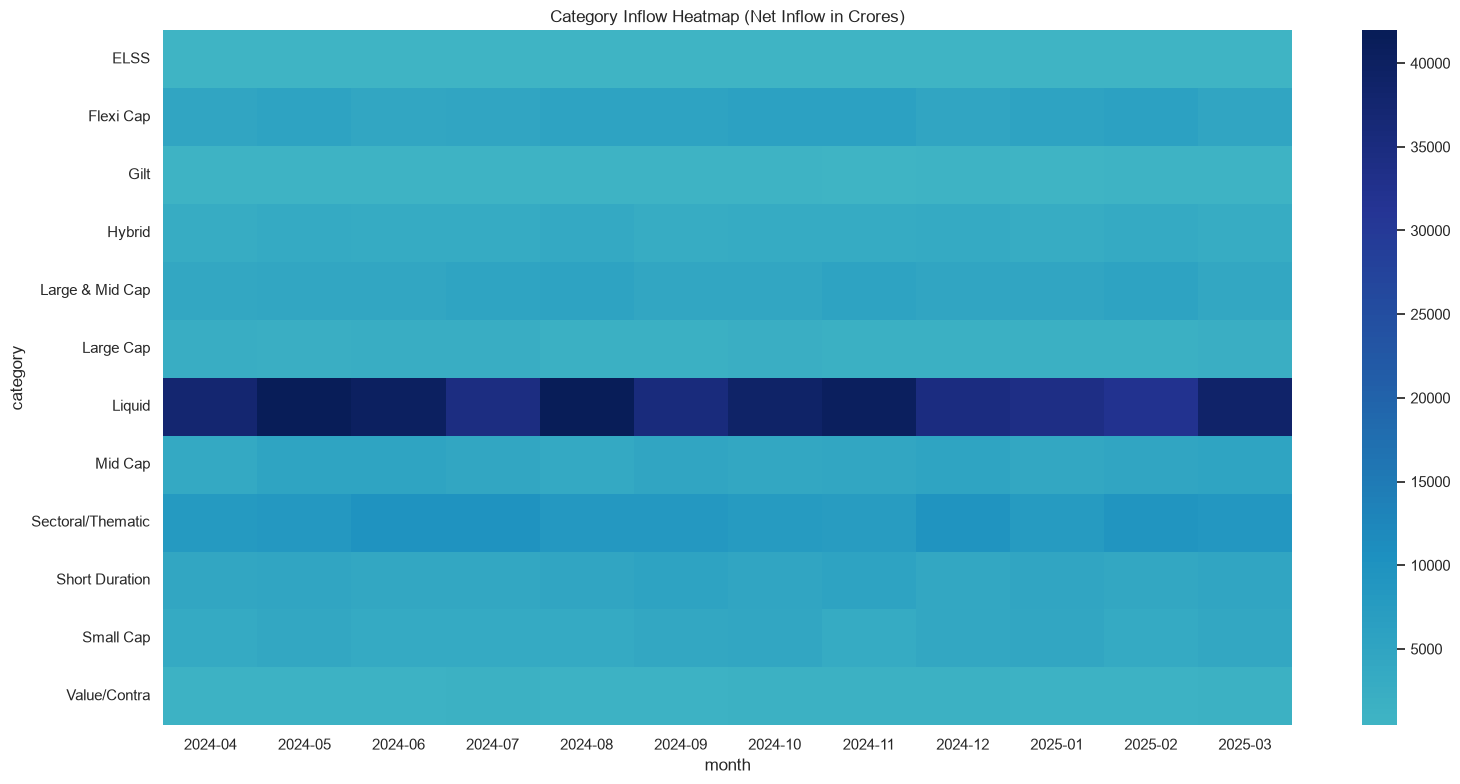

In [6]:
# 4. Category Inflow Heatmap (Seaborn)
pivot_cat = df_cat.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_cat, cmap='YlGnBu', center=0, annot=False)
plt.title('Category Inflow Heatmap (Net Inflow in Crores)')
plt.tight_layout()
plt.savefig('../reports/charts/category_heatmap.png')
plt.show()


### Finding 5: Millennial Participation
The 25-35 age group represents the largest chunk of the investor base, driving modern retail participation. *(See Age Group Pie Chart below)*

### Finding 6: SIP Affordability
While younger investors are numerous, the highest median SIP amounts originate from the 45-55 age bracket. *(See SIP Box Plot below)*

### Finding 7: Gender Diversity
There is a growing representation of female investors, though males still hold the majority share of folios. *(See Gender Split below)*

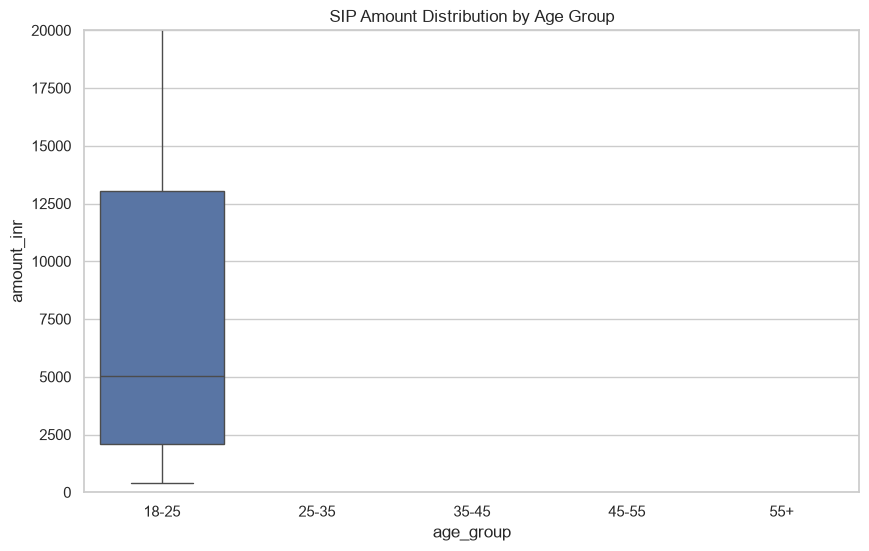

In [7]:
# 5. Investor Demographics

# Age Pie Chart
age_counts = df_tx['age_group'].value_counts()
fig_age = px.pie(values=age_counts.values, names=age_counts.index, title='Age Group Distribution')
fig_age.write_image('../reports/charts/age_pie.png')
fig_age.show()

# SIP Box Plot
sip_tx = df_tx[df_tx['transaction_type'] == 'SIP']
plt.figure(figsize=(10, 6))
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', order=['18-25', '25-35', '35-45', '45-55', '55+'])
plt.title('SIP Amount Distribution by Age Group')
plt.ylim(0, 20000) # Cap for readability
plt.savefig('../reports/charts/sip_boxplot.png')
plt.show()

# Gender Split
gender_counts = df_tx['gender'].value_counts()
fig_gender = px.pie(values=gender_counts.values, names=gender_counts.index, title='Gender Split', hole=0.4)
fig_gender.write_image('../reports/charts/gender_donut.png')
fig_gender.show()


### Finding 8: Regional Dominance
Maharashtra and Gujarat lead the country in total SIP investments, underscoring strong financial penetration in western states. *(See State-wise Bar Chart below)*

### Finding 9: T30 vs B30 Growth
Top 30 (T30) cities still hold the lion's share of assets, but Beyond 30 (B30) cities are capturing an increasingly significant slice. *(See Tier Pie Chart below)*

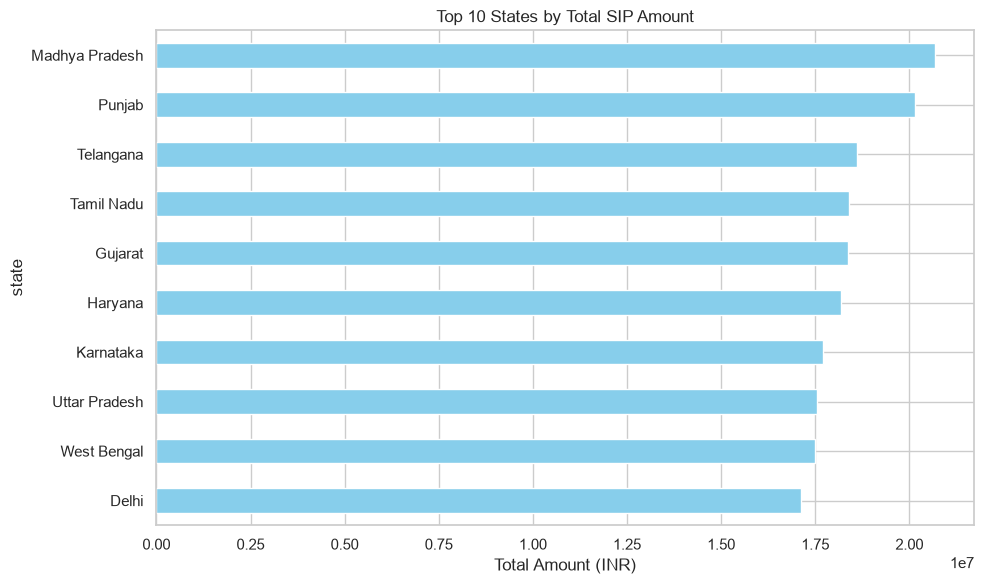

In [8]:
# 6. Geographic Distribution

# State Bar Chart
state_sip = sip_tx.groupby('state')['amount_inr'].sum().sort_values(ascending=True).tail(10)
plt.figure(figsize=(10, 6))
state_sip.plot(kind='barh', color='skyblue')
plt.title('Top 10 States by Total SIP Amount')
plt.xlabel('Total Amount (INR)')
plt.tight_layout()
plt.savefig('../reports/charts/state_bar.png')
plt.show()

# T30 vs B30
tier_counts = df_tx['city_tier'].value_counts()
fig_tier = px.pie(values=tier_counts.values, names=tier_counts.index, title='T30 vs B30 City Tier Distribution')
fig_tier.write_image('../reports/charts/tier_pie.png')
fig_tier.show()


### Finding 10: Retail Adoption
Industry folio counts nearly doubled from 13.26 Cr in early 2022 to over 26.12 Cr by the end of 2025, reflecting massive retail adoption. *(See Folio Growth Chart below)*

In [9]:
# 7. Folio Count Growth
fig = px.line(df_folio, x='month', y='total_folios_crore', title='Folio Count Growth (2022-2025)', markers=True)

# Annotate Start and End
start_val = df_folio['total_folios_crore'].iloc[0]
end_val = df_folio['total_folios_crore'].iloc[-1]

fig.add_annotation(x=df_folio['month'].iloc[0], y=start_val, text=f"{start_val} Cr", showarrow=True)
fig.add_annotation(x=df_folio['month'].iloc[-1], y=end_val, text=f"{end_val} Cr", showarrow=True)

fig.write_image('../reports/charts/folio_growth.png')
fig.show()


### Finding 11: Sectoral Correlation
The return correlation matrix for selected funds highlights that large-cap funds generally move in tandem, providing limited diversification when paired together. *(See Correlation Heatmap below)*

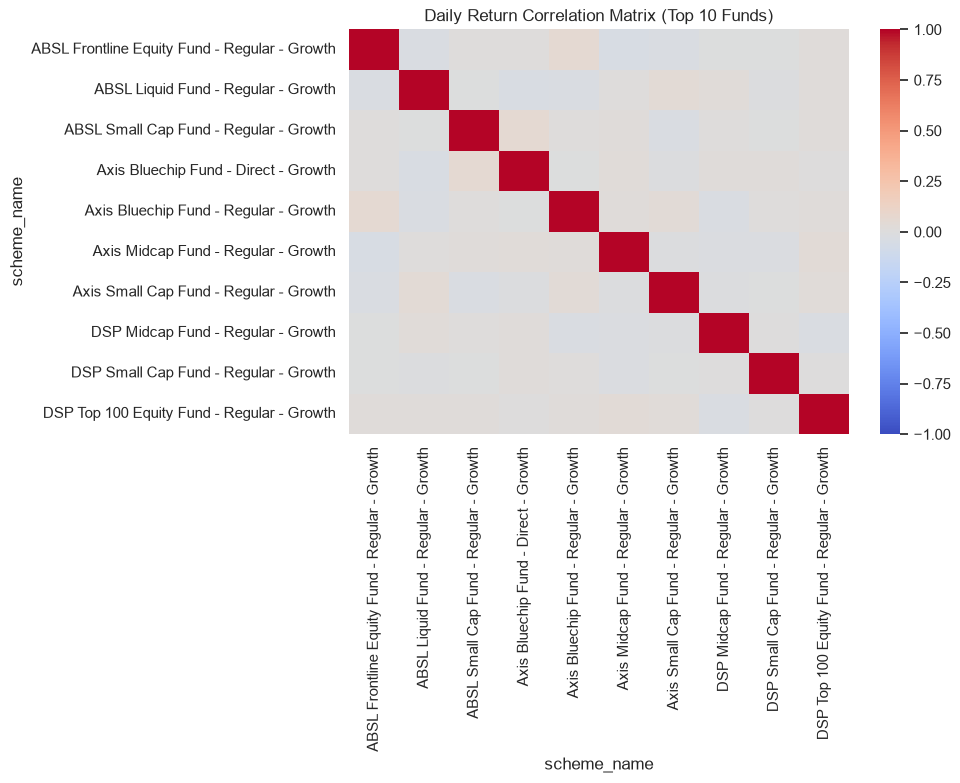

In [10]:
# 8. NAV Return Correlation Matrix
# Pivot to get daily NAV per scheme
nav_pivot = df_nav.pivot(index='date', columns='scheme_name', values='nav')

# Calculate daily returns for top 10 funds by data availability
top_10_schemes = nav_pivot.count().nlargest(10).index
returns = nav_pivot[top_10_schemes].pct_change().dropna()

corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Daily Return Correlation Matrix (Top 10 Funds)')
plt.tight_layout()
plt.savefig('../reports/charts/nav_correlation.png')
plt.show()


### Finding 12: Financial Heavyweights
Across all equity portfolios, the Financial Services and Banking sectors dominate the aggregate allocations. *(See Sector Allocation Donut below)*

In [11]:
# 9. Sector Allocation Donut
sector_weights = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)

fig = px.pie(values=sector_weights.values, names=sector_weights.index, title='Top 10 Sector Allocations (Aggregated)', hole=0.4)
fig.write_image('../reports/charts/sector_donut.png')
fig.show()
